c:\Estudos e Projetos\2024-LLM-Agronomo-Virtual\.venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (0, 0, 842, 596)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)
c:\Estudos e Projetos\2024-LLM-Agronomo-Virtual\.venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (0, 0, 842, 596)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)
C:\Users\Dirceu André Gerardi\AppData\Local\Temp\ipykernel_47164\1208594156.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  camelot.plot(tables[0], kind='contour').show()


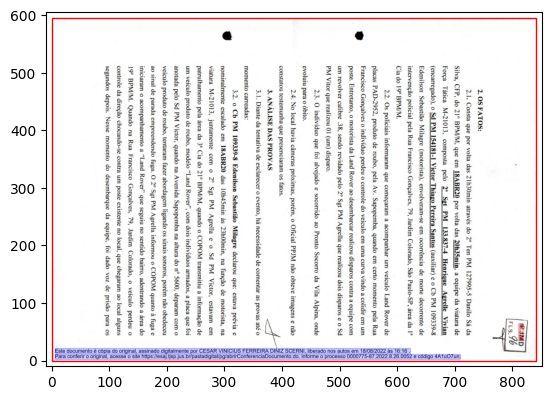

In [5]:
import pandas as pd
import os
import camelot
import requests
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

file_name = r'C:/Estudos e Projetos/(2024) Dados LAI MP/separado_doc_tjsp/unificador_documentos/pasta_teste_juncao_docs/relatório de investigações\0000775-87.2022.8.26.0052_relatório_de_investigações_unificado.pdf'

# # Usando Camelot para ler o PDF
tables = camelot.read_pdf(
    file_name,
    pages='2-end',
    flavor='stream',
    #table_area=['70.0, 415.3, 574.99, 593.45'],
    #columns=['34, 214, 392, 579, 754'],
    strip_text='\r',
    #row_tol=4
    )

# Plotar a primeira tabela
# text, grid, contour, line, joint, textedge
camelot.plot(tables[0], kind='contour').show()
# Salvar o plot como uma imagem temporária


#print(tables[0].df)

#tables[0].df.to_csv('C:\Estudos e Projetos\(2024) ETL_pdf\etl-pdf\documentos\GatewayPDF_x.csv', sep='|', encoding='utf-8', index=False)

In [12]:
from marker.converters.pdf import PdfConverter
from marker.models import create_model_dict
from marker.config.parser import ConfigParser
 

config = {
    "output_format": "json",
    "ADDITIONAL_KEY": "VALUE"
}
config_parser = ConfigParser(config)

converter = PdfConverter(
    config=config_parser.generate_config_dict(),
    artifact_dict=create_model_dict(),
    processor_list=config_parser.get_processors(),
    renderer=config_parser.get_renderer()
)
rendered = converter(r"C:\Estudos e Projetos\2024-LLM-Agronomo-Virtual\pdf\0000342-20.2021.8.26.0052_laudo_iml_pags_37-47.pdf")

rendered

Loaded layout model datalab-to/surya_layout on device cpu with dtype torch.float32
Loaded texify model datalab-to/texify on device cpu with dtype torch.float32
Loaded recognition model vikp/surya_rec2 on device cpu with dtype torch.float32
Loaded table recognition model datalab-to/surya_tablerec on device cpu with dtype torch.float32
Loaded detection model vikp/surya_det3 on device cpu with dtype torch.float32


Recognizing Text: 100%|██████████| 11/11 [03:19<00:00, 18.12s/it]
Recognizing equations: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]


JSONOutput(children=[JSONBlockOutput(id='/page/0/Page/97', block_type='Page', html="<content-ref src='/page/0/PageHeader/20'></content-ref><content-ref src='/page/0/Picture/0'></content-ref><content-ref src='/page/0/Text/1'></content-ref><content-ref src='/page/0/Picture/2'></content-ref><content-ref src='/page/0/Text/21'></content-ref><content-ref src='/page/0/Text/3'></content-ref><content-ref src='/page/0/SectionHeader/4'></content-ref><content-ref src='/page/0/SectionHeader/5'></content-ref><content-ref src='/page/0/Text/6'></content-ref><content-ref src='/page/0/Text/7'></content-ref><content-ref src='/page/0/Picture/8'></content-ref><content-ref src='/page/0/Text/9'></content-ref><content-ref src='/page/0/Text/10'></content-ref><content-ref src='/page/0/Text/11'></content-ref><content-ref src='/page/0/Text/12'></content-ref><content-ref src='/page/0/Text/13'></content-ref><content-ref src='/page/0/SectionHeader/14'></content-ref><content-ref src='/page/0/Text/15'></content-ref><c

In [10]:
print(rendered)

NameError: name 'rendered' is not defined

In [11]:
## modelo funcionando

import pytest
from marker.converters.pdf import PdfConverter
from marker.renderers.markdown import MarkdownOutput
import time
import glob
import pandas as pd
from tqdm import tqdm

# Define the test function
@pytest.mark.output_format("markdown")
def test_pdf_converter(converter, temp_pdf):
    markdown_output: MarkdownOutput = converter(temp_pdf)
    markdown = markdown_output.markdown
    assert markdown.startswith("#")
    return markdown

tipos = [
    "decisão",
    "inquérito policial",
    "laudo iml",
    "laudo médico",
    "laudo médico (digitalizado)",
    "laudo pericial",
    "laudo pericial (digitalizado)",
    "relatório de investigações",
    "relatório final",
    "relatório final digitalizado",
    "sentença"
]

# sentença, decisão
for pasta in tipos:
    source = glob.glob(f"C:/Estudos e Projetos/(2024) Dados LAI MP/separado_doc_tjsp/unificador_documentos/pasta_teste_juncao_docs/{pasta}/*.pdf")[0:2]
    tipo_doc = pasta
    md_txt = []
    for item in tqdm(source):
        try:
            # Cria a a variável para armazenar o tempo inicial
            ini = time.time()
            # extrai metadados
            numero_tj = item.split("\\")[1].split("_")[0]
            tipo_doc = item.split("\\")[1].split("_")[1]

            md = test_pdf_converter(converter, item.replace("\\", "/"))
            print(md)
            # salva o tempo final
            tempo_exec = time.time() - ini
            md_txt.append([numero_tj, tipo_doc, md, tempo_exec])
            dados = pd.DataFrame(md_txt, columns=['numero_tj', 'tipo_doc', 'texto_total', 'fim'])
            # Salvar o resultado em um arquivo Excel
            dados.to_csv(f'lista_raspagem_pdf_{tipo_doc}.csv', index=False)
        except Exception as e:
            print(f"Erro ao extrair texto do PDF {item}: {e}")
            continue


Recognizing Text: 100%|██████████| 2/2 [00:28<00:00, 14.35s/it]
Recognizing equations: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
 50%|█████     | 1/2 [00:31<00:31, 31.72s/it]

Erro ao extrair texto do PDF C:/Estudos e Projetos/(2024) Dados LAI MP/separado_doc_tjsp/unificador_documentos/pasta_teste_juncao_docs/decisão\0000008-83.2021.8.26.0052_decisão_unificado.pdf: 'JSONOutput' object has no attribute 'markdown'


100%|██████████| 1/1 [00:00<00:00, 27.15it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing equations: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
100%|██████████| 2/2 [00:32<00:00, 16.43s/it]


Erro ao extrair texto do PDF C:/Estudos e Projetos/(2024) Dados LAI MP/separado_doc_tjsp/unificador_documentos/pasta_teste_juncao_docs/decisão\0000037-31.2024.8.26.0052_decisão_unificado.pdf: 'JSONOutput' object has no attribute 'markdown'


  0%|          | 0/2 [00:21<?, ?it/s]


KeyboardInterrupt: 

In [13]:
test_pdf_converter(converter, "C:/Estudos e Projetos/2024-LLM-Agronomo-Virtual/pdf/0000342-20.2021.8.26.0052_laudo_iml_pags_37-47.pdf")

Recognizing Text: 100%|██████████| 11/11 [03:21<00:00, 18.34s/it]
Recognizing equations: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]


AttributeError: 'JSONOutput' object has no attribute 'markdown'